<a href="https://colab.research.google.com/github/anushabenze23-del/customer_churnprediction_machinelearning/blob/machinelearning/Customer_Churn_Predictation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM STATEMENT:CUSTOMER CHURN PREDICTATION

IMPORT THE LIBRARIES

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

DATA GATHERING

In [12]:
df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv.zip')
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


EDA

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [13]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [15]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


NULL VALUE IMPULSION

In [16]:
df.isna().sum()*100/len(df)

,0
CustomerID,0.0
Age,0.0
Gender,0.0
Tenure,0.0
Usage Frequency,0.0
Support Calls,0.0
Payment Delay,0.0
Subscription Type,0.0
Contract Length,0.0
Total Spend,0.0


In [17]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("")


CustomerID
[    1     2     3 ... 64372 64373 64374]

Age
[22 41 47 35 53 30 54 36 65 46 56 31 42 59 29 45 62 48 55 64 25 44 28 34
 24 27 61 57 37 51 18 23 60 40 26 52 43 19 58 33 20 39 32 38 21 63 49 50]

Gender
['Female' 'Male']

Tenure
[25 28 27  9 58 41 37 36 20  8 42 13  2 46 21  1 54 40 39 50 59 60 44 23
 26 31 30 51 45 19 14 24 15 47  3 17 22 57 34 29 33 35 56  5 55 48  6 32
 16 10  7 43 52 53 38  4 11 18 49 12]

Usage Frequency
[14 28 10 12 24 15 11  5  4 27 23  7 17  3 30  2 19 20 18  8  6 21 26 16
 25 13 29  9 22  1]

Support Calls
[ 4  7  2  5  9 10  0  6  1  3  8]

Payment Delay
[27 13 29 17  2 10 28 18  8 23 21 14 25  3  6 15  1  9 30  4  0 11 16  7
 24 22 12 26 20 19  5]

Subscription Type
['Basic' 'Standard' 'Premium']

Contract Length
['Monthly' 'Annual' 'Quarterly']

Total Spend
[ 598  584  757  232  533  500  574  323  687  995  526  187  758  438
  663  677  636  127  396  202  925  463  449  373  460  166  615  696
  678  792  812  156  611  943  329  493  384  515 

In [18]:
df['Subscription Type'].value_counts()


,count
Subscription Type,
Standard,21502
Basic,21451
Premium,21421


In [19]:
df['Gender'].value_counts()

,count
Gender,
Female,34353
Male,30021


In [21]:
df.replace({ "Gender": {'Male': 0, 'Female': 1}}, inplace=True)

In [22]:
df['Contract Length'].value_counts()

,count
Contract Length,
Monthly,22130
Annual,21410
Quarterly,20834


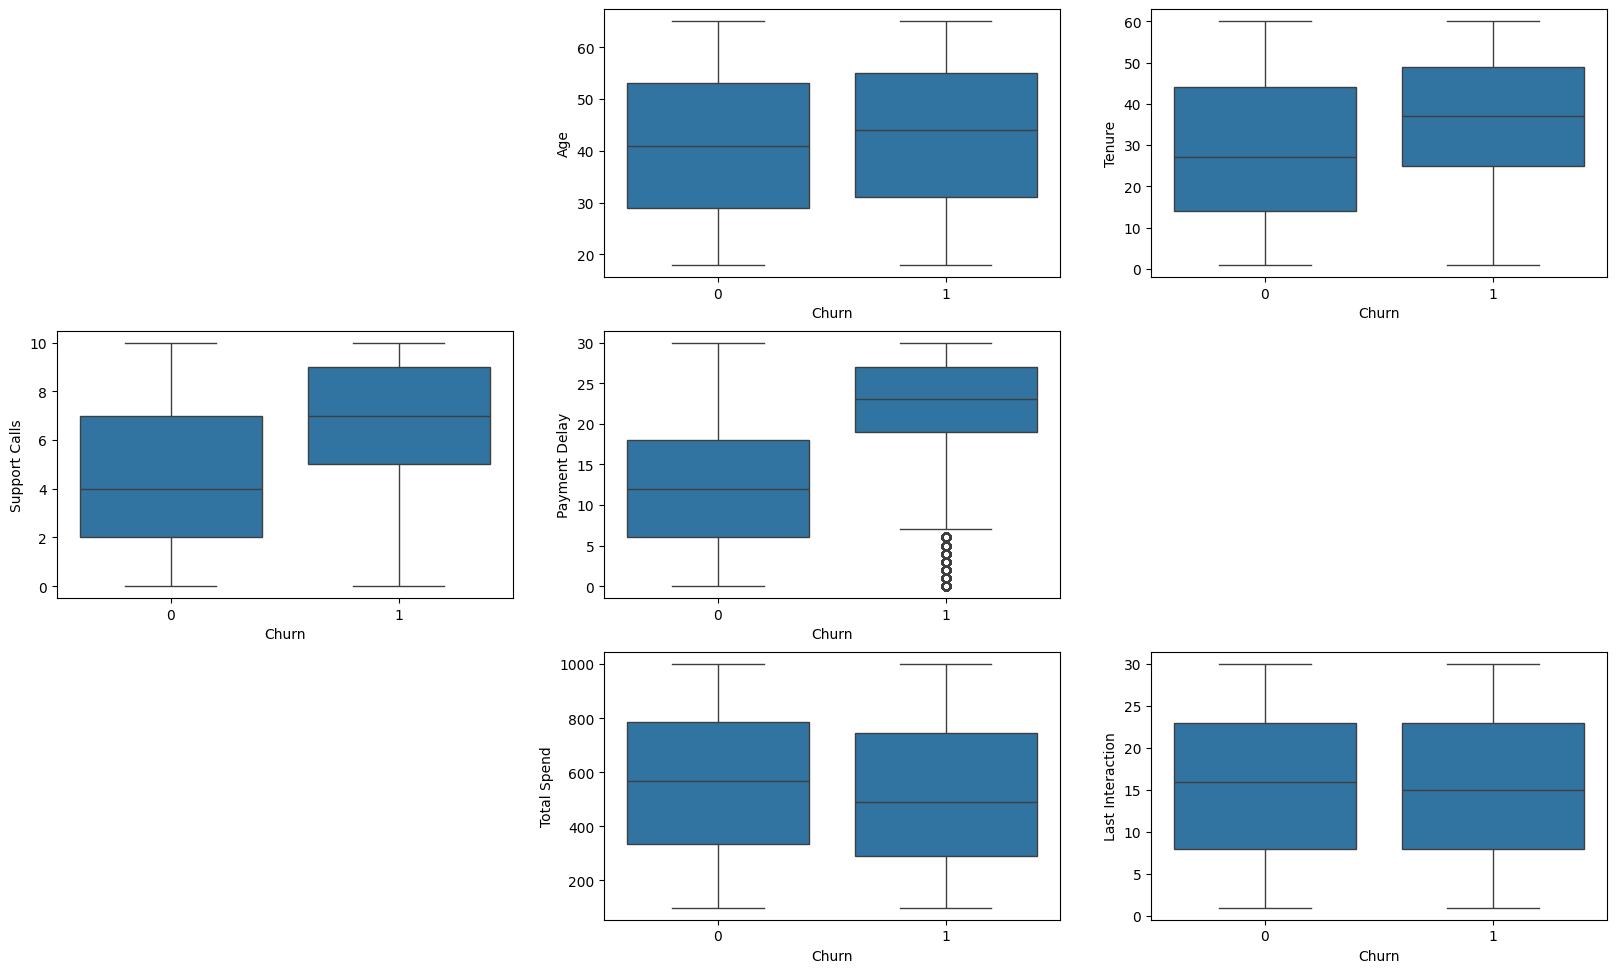

In [47]:
#VIZUALIZATION OF NUMERICAL VARIABLES

plt.figure(figsize=(20, 16))


plt.subplot(4, 3, 2)
sns.boxplot(x='Churn', y='Age', data=df)

plt.subplot(4, 3, 3)
sns.boxplot(x='Churn', y='Tenure', data=df)

plt.subplot(4, 3, 4)
sns.boxplot(x='Churn', y='Support Calls', data=df)

plt.subplot(4, 3, 5)
sns.boxplot(x='Churn', y='Payment Delay', data=df)

plt.subplot(4, 3, 8)
sns.boxplot(x='Churn', y='Total Spend', data=df)

plt.subplot(4, 3, 9)
sns.boxplot(x='Churn', y='Last Interaction', data=df)

plt.show()


In [30]:
categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

numerical_features = ['Age', 'Tenure', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction',]

df_features = df[numerical_features + categorical_features + ['Churn']]
df_features.head(10)


,Age,Tenure,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender,Subscription Type,Contract Length,Churn
0,22,25,4,27,598,9,1,Basic,Monthly,1
1,41,28,7,13,584,20,1,Standard,Monthly,0
2,47,27,2,29,757,21,0,Premium,Annual,0
3,35,9,5,17,232,18,0,Premium,Quarterly,0
4,53,58,9,2,533,18,1,Standard,Annual,0
5,30,41,10,10,500,29,0,Premium,Monthly,0
6,47,37,9,28,574,14,1,Basic,Quarterly,1
7,54,36,0,18,323,16,1,Standard,Monthly,0
8,36,20,10,8,687,8,0,Basic,Monthly,0
9,65,8,2,23,995,10,0,Basic,Annual,0


TESTING AND TRAINING

In [31]:
def train_test_split_and_features(df_features):
    y = df_features["Churn"]
    x = df_features.drop('Churn', axis=1)
    x = pd.get_dummies(x, dtype=int)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test, features

x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)


   Age  Tenure  Support Calls  Payment Delay  Total Spend  Last Interaction  \
0   22      25              4             27          598                 9   
1   41      28              7             13          584                20   
2   47      27              2             29          757                21   
3   35       9              5             17          232                18   
4   53      58              9              2          533                18   

   Gender  Subscription Type_Basic  Subscription Type_Premium  \
0       1                        1                          0   
1       1                        0                          0   
2       0                        0                          1   
3       0                        0                          1   
4       1                        0                          0   

   Subscription Type_Standard  Contract Length_Annual  \
0                           0                       0   
1                   

In [32]:
x_train.head(10)

,Age,Tenure,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
41100,48,17,8,29,685,14,1,0,1,0,0,0,1
61149,22,23,10,27,997,7,1,1,0,0,0,1,0
36345,59,42,8,3,837,26,0,0,0,1,0,1,0
57231,52,18,4,27,196,26,1,1,0,0,1,0,0
48153,65,60,6,19,734,19,0,0,0,1,0,1,0
2460,52,49,0,6,904,19,1,0,0,1,0,0,1
20261,64,11,3,9,503,14,1,0,1,0,0,1,0
7906,30,27,10,14,538,29,1,0,1,0,0,0,1
63525,23,39,6,30,921,21,0,1,0,0,1,0,0
48286,26,60,9,17,969,17,0,0,1,0,1,0,0


FIT AND EVALUATE MODEL

In [33]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=5, min_samples_split=0.01, max_features=0.8, max_samples=0.8):
    random_forest = RandomForestClassifier(random_state=0,\
                                         max_depth=max_depth,\
                                         min_samples_split=min_samples_split,\
                                         max_features=max_features,\
                                         max_samples=max_samples)

    model = random_forest.fit(x_train, y_train)
    random_forest_predict = random_forest.predict(x_test)
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)

    print("Confussion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:", random_forest_acc_score * 100, '\n')
    print(classification_report(y_test, random_forest_predict))

    return model


In [34]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)


Confussion matrix
[[6670  107]
 [ 656 5442]]


Accuracy of Random Forest: 94.07378640776699 

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      6777
           1       0.98      0.89      0.93      6098

    accuracy                           0.94     12875
   macro avg       0.95      0.94      0.94     12875
weighted avg       0.94      0.94      0.94     12875



TRYING DIFFERENT PARAMETER TO IDENTIFY BEST ONE

In [42]:
param_grid = [
    {'max_depth': [3, 5, 7, 10], 'min_samples_split': [0.01, 0.03, 0.07, 0.1],
     'max_features': [0.7, 0.8, 0.9, 1.0],
     'max_samples': [0.7, 0.8, 0.9, 1.0]}]

from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
search = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, verbose=5)
search.fit(x_train, y_train)


Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.911 total time=   4.1s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.880 total time=   2.3s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.911 total time=   2.3s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.891 total time=   2.3s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.883 total time=   2.9s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.911 total time=   2.6s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.889 total time=   4.5s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.893 total time=   4.6s


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [3, 5, 7, 10],
                          'max_features': [0.7, 0.8, 0.9, 1.0],
                          'max_samples': [0.7, 0.8, 0.9, 1.0],
                          'min_samples_split': [0.01, 0.03, 0.07, 0.1]}],
             verbose=5)

In [43]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score', inplace=True, ascending=False)
results.head(10)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
204,4.731526,0.365729,0.071919,0.001584,10,0.7,1.0,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.94466,0.940291,0.944757,0.943592,0.943101,0.943280,0.001622,1
200,4.319020,0.362892,0.071196,0.001221,10,0.7,0.9,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.94466,0.940291,0.944757,0.943592,0.943101,0.943280,0.001622,1
172,5.385903,0.443615,0.072693,0.011814,7,0.9,1.0,0.01,"{'max_depth': 7, 'max_features': 0.9, 'max_sam...",0.94466,0.940291,0.944757,0.943495,0.943101,0.943261,0.001618,3
236,5.428608,0.329333,0.071615,0.005013,10,0.9,1.0,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.94466,0.940291,0.944757,0.943495,0.943101,0.943261,0.001618,3
220,5.189661,0.361262,0.076603,0.009505,10,0.8,1.0,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.94466,0.940291,0.944757,0.943495,0.943101,0.943261,0.001618,3
144,4.030125,0.211489,0.072018,0.006608,7,0.8,0.7,0.01,"{'max_depth': 7, 'max_features': 0.8, 'max_sam...",0.94466,0.940291,0.944757,0.943495,0.943101,0.943261,0.001618,3
212,4.601308,0.352876,0.070652,0.002462,10,0.8,0.8,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.94466,0.940291,0.944757,0.943495,0.943101,0.943261,0.001618,3
140,4.595025,0.381107,0.075761,0.006748,7,0.7,1.0,0.01,"{'max_depth': 7, 'max_features': 0.7, 'max_sam...",0.94466,0.940291,0.944757,0.943398,0.943101,0.943242,0.001616,8
152,4.768467,0.447417,0.071997,0.003547,7,0.8,0.9,0.01,"{'max_depth': 7, 'max_features': 0.8, 'max_sam...",0.94466,0.940291,0.944660,0.943495,0.943101,0.943242,0.001601,8
160,4.202965,0.348993,0.072579,0.007869,7,0.9,0.7,0.01,"{'max_depth': 7, 'max_features': 0.9, 'max_sam...",0.94466,0.940291,0.944660,0.943495,0.943101,0.943242,0.001601,8


In [44]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_save.csv", index=False)

search.best_params_


{'max_depth': 10,
 'max_features': 0.7,
 'max_samples': 0.9,
 'min_samples_split': 0.01}

MODEL WITH BEST PARAMETER

Confussion matrix
[[6777    0]
 [ 672 5426]]


Accuracy of Random Forest: 94.78058252427184 

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      6777
           1       1.00      0.89      0.94      6098

    accuracy                           0.95     12875
   macro avg       0.95      0.94      0.95     12875
weighted avg       0.95      0.95      0.95     12875



<BarContainer object of 13 artists>

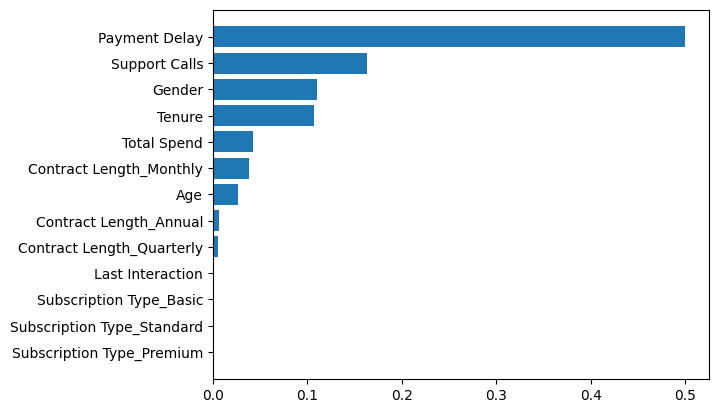

In [46]:

model = fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=10, min_samples_split=0.01,                               max_features=0.7, max_samples=1.0)


importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance', 'feature']
importances.sort_values(by='importance', ascending=True, inplace=True)


import matplotlib.pyplot as plt
plt.barh(importances.feature, importances.importance)